# Scraping Terrenos — Processed to Gold

Transforma `data/raw/scraping_manual/preprocessed/scraping_land_preprocessed.csv` en el gold dataset `data/gold/final_land_scraping.csv` listo para modelado ML.

**Pipeline:**
1. Carga del dataset y filtrado por municipio (Santa Cruz de Bezana)
2. Eliminación de duplicados y outliers
3. Filtrado de categorías de suelo con pocos registros
4. Exclusión de features con data leakage
5. Auditoría y selección de features
6. Log-transformación del target (`log_precio`)
7. Target encoding de `municipio` (persistido como artefacto, no incluido en el dataset)
8. One-hot encoding de `tipo_suelo`
9. Exportación al gold layer (sobreescribe los archivos en cada ejecución)

**Artefactos generados en `data/gold/`:**

- `final_land_scraping.csv`: dataset principal listo para entrenar modelos.
- `municipio_encoding_map.json`: diccionario `{municipio: encoding_numerico}` necesario para predecir nuevos casos.
- `feature_columns.json`: lista ordenada de columnas del dataset, necesaria para construir vectores de predicción coherentes.


In [122]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

## 1. Carga del dataset

Se carga el archivo procesado y se trabaja sobre una copia para no modificar el original.

In [123]:
df_raw = pd.read_csv('../../data/raw/scraping_manual/preprocessed/scraping_land_preprocessed.csv', sep=';')
df = df_raw.copy()

# Filtrado: solo Santa Cruz de Bezana
df = df[df['municipio'].str.strip().str.lower() == 'santa cruz de bezana'].copy()

print(f'Shape inicial (Bezana): {df.shape}')
df.head(3)

Shape inicial (Bezana): (76, 8)


,titulo,municipio,precio_eur,superficie_m2,tipo_suelo,vendido_con_descuento,es_urbano_o_urbanizable,precio_m2
2,"Calle de la Arnia, Soto de la Marina, Santa Cr...",Santa Cruz de Bezana,1290000,3217.0,Urbano (solar),False,True,400.994716
4,"Avenida Playa San Juan de la Canal, Soto de la...",Santa Cruz de Bezana,1500000,6518.0,Urbano (solar),False,True,230.131942
14,"Avenida Juan de Herrera, s/n, Maoño, Santa Cru...",Santa Cruz de Bezana,115000,885.0,Urbanizable,False,True,129.943503


In [124]:
print('Tipos de dato:')
print(df.dtypes)
print()
print('Nulos:')
print(df.isnull().sum())

Tipos de dato:
titulo                         str
municipio                      str
precio_eur                   int64
superficie_m2              float64
tipo_suelo                     str
vendido_con_descuento         bool
es_urbano_o_urbanizable       bool
precio_m2                  float64
dtype: object

Nulos:
titulo                     0
municipio                  0
precio_eur                 0
superficie_m2              0
tipo_suelo                 0
vendido_con_descuento      0
es_urbano_o_urbanizable    0
precio_m2                  0
dtype: int64


## 2. Eliminación de duplicados y outliers

Antes de cualquier transformación, se aplican dos filtros de calidad sobre el dataset:

**Duplicados.** El proceso de scraping puede capturar el mismo terreno republicado por agencias distintas o en fechas diferentes. Estos registros aparecen como filas con valores idénticos en `precio_eur`, `superficie_m2` y `tipo_suelo`. Mantenerlos introduce un peso artificial en los modelos predictivos: una parcela que aparezca tres veces influiría tres veces más que el resto, sesgando las predicciones hacia sus características concretas.

**Outliers de precio unitario (€/m²).** El portal Idealista incluye anuncios cuyo precio unitario es manifiestamente atípico respecto al resto del mercado. Estos casos suelen corresponder a operaciones singulares (ámbitos en gestión parada cuyo precio refleja la urgencia de venta del propietario, parcelas con cargas o servidumbres no especificadas, errores de publicación) y distorsionan el aprendizaje de los modelos al introducir relaciones precio-superficie que no son representativas del mercado real.

Se identifican los outliers mediante el criterio del rango intercuartílico (IQR) sobre el precio unitario en escala logarítmica, descartando los registros cuyo `log(precio/superficie)` queda fuera del intervalo $[Q_1 - 1{,}5 \cdot IQR;\; Q_3 + 1{,}5 \cdot IQR]$. La escala logarítmica es la apropiada porque los precios unitarios siguen una distribución asimétrica positiva, en la que un criterio sobre la escala lineal sería excesivamente permisivo en el extremo superior y excesivamente estricto en el inferior.


Registros antes de deduplicar: 76
Duplicados eliminados:         15
Registros tras deduplicar:     61

Umbrales IQR sobre log(€/m²):
  Q1 = 4.605  (100.0 €/m²)
  Q3 = 5.460  (235.1 €/m²)
  Intervalo aceptado: [27.7 - 847.4] €/m²

Outliers detectados: 9

Muestra de outliers eliminados (primeros 10):
    precio_eur  superficie_m2      tipo_suelo  eur_m2
9       180000        12925.0  Urbano (solar)    13.9
18      101000        15292.0  No urbanizable     6.6
20      165000         8940.0     Urbanizable    18.5
23      225000        29839.0     Urbanizable     7.5
24     1435000        53786.0     Urbanizable    26.7
32      200000        12925.0          Urbano    15.5
35      225000        29435.0     Urbanizable     7.6
43       39900         1560.0  No urbanizable    25.6
57       20000         1611.0  No urbanizable    12.4

Registros tras eliminar outliers: 52


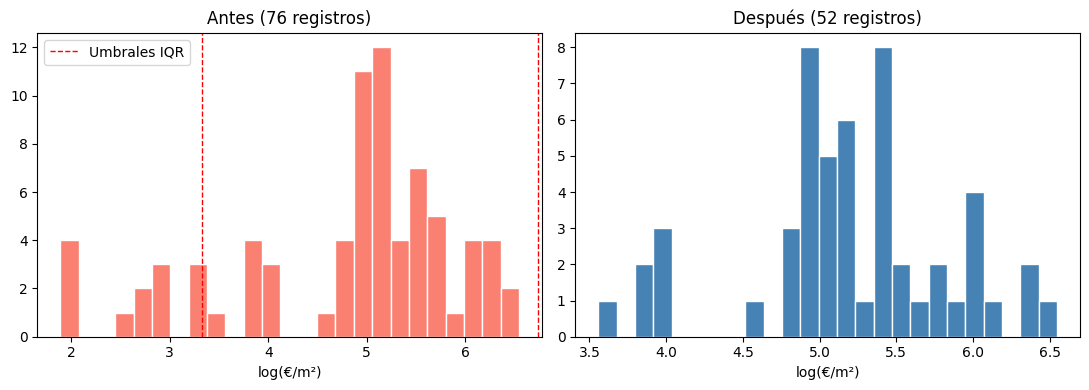

In [125]:
# --- 2.1. Duplicados ---
n_antes = len(df)
df = df.drop_duplicates(subset=['precio_eur', 'superficie_m2', 'tipo_suelo']).reset_index(drop=True)
n_duplicados = n_antes - len(df)

print(f'Registros antes de deduplicar: {n_antes}')
print(f'Duplicados eliminados:         {n_duplicados}')
print(f'Registros tras deduplicar:     {len(df)}')

# --- 2.2. Outliers por precio unitario (IQR sobre log(€/m²)) ---
precio_m2 = df['precio_eur'] / df['superficie_m2']
log_pm2 = np.log(precio_m2)

q1, q3 = log_pm2.quantile(0.25), log_pm2.quantile(0.75)
iqr = q3 - q1
lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr

mask_outlier = (log_pm2 < lo) | (log_pm2 > hi)
n_outliers = int(mask_outlier.sum())

print(f'\nUmbrales IQR sobre log(€/m²):')
print(f'  Q1 = {q1:.3f}  ({np.exp(q1):.1f} €/m²)')
print(f'  Q3 = {q3:.3f}  ({np.exp(q3):.1f} €/m²)')
print(f'  Intervalo aceptado: [{np.exp(lo):.1f} - {np.exp(hi):.1f}] €/m²')
print(f'\nOutliers detectados: {n_outliers}')

if n_outliers > 0:
    print('\nMuestra de outliers eliminados (primeros 10):')
    cols_show = ['precio_eur', 'superficie_m2', 'tipo_suelo']
    out = df[mask_outlier][cols_show].copy()
    out['eur_m2'] = (df.loc[mask_outlier, 'precio_eur'] / df.loc[mask_outlier, 'superficie_m2']).round(1)
    print(out.head(10).to_string())

df = df[~mask_outlier].reset_index(drop=True)
print(f'\nRegistros tras eliminar outliers: {len(df)}')

# --- 2.3. Visualización del antes/después ---
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(np.log(df_raw['precio_eur'][df_raw['municipio'].str.strip().str.lower()=='santa cruz de bezana'] / df_raw['superficie_m2'][df_raw['municipio'].str.strip().str.lower()=='santa cruz de bezana']), bins=25, color='salmon', edgecolor='white')
axes[0].axvline(lo, color='red', linestyle='--', linewidth=1, label='Umbrales IQR')
axes[0].axvline(hi, color='red', linestyle='--', linewidth=1)
axes[0].set_title(f'Antes ({n_antes} registros)')
axes[0].set_xlabel('log(€/m²)')
axes[0].legend()

axes[1].hist(np.log(df['precio_eur'] / df['superficie_m2']), bins=25, color='steelblue', edgecolor='white')
axes[1].set_title(f'Después ({len(df)} registros)')
axes[1].set_xlabel('log(€/m²)')

plt.tight_layout()
plt.show()


## 3. Filtrado de categorías de suelo con pocos registros

Se analiza la distribución de `tipo_suelo` para identificar categorías con muestra insuficiente para modelar.

Registros por categoría de suelo:
tipo_suelo
Urbano            23
Urbano (solar)    17
Urbanizable        8
No urbanizable     4
Name: count, dtype: int64


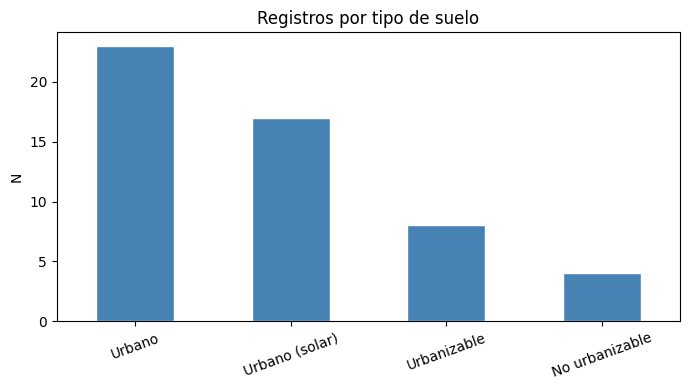

In [126]:
conteo_tipo_suelo = df['tipo_suelo'].value_counts()
print('Registros por categoría de suelo:')
print(conteo_tipo_suelo)

fig, ax = plt.subplots(figsize=(7, 4))
conteo_tipo_suelo.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Registros por tipo de suelo')
ax.set_xlabel('')
ax.set_ylabel('N')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

In [127]:
# Solo 'Industrial' tiene registros insuficientes (4 observaciones).
# 'Urbanizable' se conserva aunque quede por debajo del umbral, porque
# necesitamos mantener esa tipología en el gold final.
# Umbral: se eliminan categorías con menos de 10 registros, salvo las reservadas.

UMBRAL_MIN = 10
categorias_reservadas = ['Urbanizable', 'Urbano', 'Urbano (solar)']
categorias_validas = [
    categoria for categoria, conteo in conteo_tipo_suelo.items()
    if conteo >= UMBRAL_MIN or categoria in categorias_reservadas
 ]
categorias_eliminadas = [
    categoria for categoria, conteo in conteo_tipo_suelo.items()
    if conteo < UMBRAL_MIN and categoria not in categorias_reservadas
 ]

print(f'Categorías conservadas: {categorias_validas}')
print(f'Categorías eliminadas (< {UMBRAL_MIN} registros, salvo reservadas): {categorias_eliminadas}')

df = df[df['tipo_suelo'].isin(categorias_validas)].copy()
print(f'\nShape tras filtrado: {df.shape}')

Categorías conservadas: ['Urbano', 'Urbano (solar)', 'Urbanizable']
Categorías eliminadas (< 10 registros, salvo reservadas): ['No urbanizable']

Shape tras filtrado: (48, 8)


## 4. Exclusión de features con data leakage

- **`precio_m2`**: derivada directamente del target (`precio_eur / superficie_m2`). Usarla como feature introduce data leakage — el modelo aprendería a invertir la fórmula en lugar de aprender patrones reales.
- **`titulo`**: texto libre con barrio y municipio. El municipio ya está capturado en `municipio`. Procesarlo requeriría NLP fuera del alcance de este pipeline.

In [128]:
cols_excluir = ['precio_m2', 'titulo']
df = df.drop(columns=cols_excluir)

print(f'Columnas tras exclusión: {df.columns.tolist()}')

Columnas tras exclusión: ['municipio', 'precio_eur', 'superficie_m2', 'tipo_suelo', 'vendido_con_descuento', 'es_urbano_o_urbanizable']


## 5. Auditoría y selección de features

Antes de continuar con la transformación del target y la codificación de variables, se realiza una auditoría sistemática de las features disponibles para identificar columnas que no aportan información al modelo o que introducen problemas estadísticos. La auditoría se basa en cuatro criterios objetivos:

1. **Varianza nula o casi nula**: features constantes o binarias con menos del 5% de la muestra en la categoría minoritaria, que no permiten establecer relaciones predictivas estadísticamente significativas.

2. **Redundancia exacta**: features con correlación superior a 0,99 con otra feature, que generan colinealidad perfecta y desestabilizan los modelos.

3. **Correlación con el target**: features con correlación absoluta inferior a 0,05 con el target, que actúan como ruido en el aprendizaje.

4. **Valores nulos**: features con valores ausentes que requerirían imputación.

Las decisiones de eliminación derivadas de esta auditoría se documentan explícitamente para garantizar la trazabilidad metodológica.

In [129]:
# Construimos previamente log_precio para poder calcular correlaciones con el target
log_precio_aux = np.log(df['precio_eur'])

print('='*70)
print('AUDITORIA DE FEATURES')
print('='*70)
features_audit = [c for c in df.columns if c not in ['precio_eur']]
print(f'Dataset: {df.shape[0]} filas, {len(features_audit)} features candidatas\n')

# --- 1. Varianza nula o casi nula ---
print('[1] Features con varianza nula o casi nula')
print('-'*70)
problemas_varianza = []
for col in features_audit:
    if df[col].dtype == object:
        continue
    nunique = df[col].nunique()
    if nunique == 1:
        print(f'  X {col}: VALOR CONSTANTE')
        problemas_varianza.append(col)
    elif nunique == 2:
        prop_min = df[col].value_counts(normalize=True).min()
        if prop_min < 0.05:
            print(f'  ! {col}: binaria muy desbalanceada ({prop_min*100:.1f}% en minoria)')

# --- 2. Redundancia (correlaciones >0.99) ---
print('\n[2] Features perfectamente correlacionadas (r > 0,99)')
print('-'*70)
num_cols = df[features_audit].select_dtypes(include=[np.number]).columns.tolist()
pares_redundantes = []
if len(num_cols) >= 2:
    corr = df[num_cols].corr().abs()
    np.fill_diagonal(corr.values, 0)
    for i in range(len(num_cols)):
        for j in range(i+1, len(num_cols)):
            if corr.iloc[i, j] > 0.99:
                pares_redundantes.append((num_cols[i], num_cols[j], corr.iloc[i, j]))
                print(f'  X {num_cols[i]} <-> {num_cols[j]}: r = {corr.iloc[i, j]:.3f}')
if not pares_redundantes:
    print('  OK Sin correlaciones >0.99 entre features numericas')

# --- 3. Correlación con el target ---
print('\n[3] Correlacion de cada feature con log(precio_eur)')
print('-'*70)
correlaciones = []
for col in num_cols:
    r = df[col].corr(log_precio_aux)
    correlaciones.append((col, r))
correlaciones.sort(key=lambda x: -abs(x[1]) if not np.isnan(x[1]) else 0)
for col, r in correlaciones:
    flag = ''
    if np.isnan(r):
        flag = ' ! NaN (varianza nula)'
    elif abs(r) < 0.05:
        flag = ' ! correlacion muy baja'
    print(f'  {col:<35} r = {r:+.3f}{flag}')

# --- 4. Nulos ---
print('\n[4] Valores nulos')
print('-'*70)
nulos = df[features_audit].isnull().sum()
nulos = nulos[nulos > 0]
if len(nulos) > 0:
    for col, n in nulos.items():
        print(f'  ! {col}: {n} nulos')
else:
    print('  OK Sin nulos')

AUDITORIA DE FEATURES
Dataset: 48 filas, 5 features candidatas

[1] Features con varianza nula o casi nula
----------------------------------------------------------------------
  X municipio: VALOR CONSTANTE
  ! vendido_con_descuento: binaria muy desbalanceada (2.1% en minoria)

[2] Features perfectamente correlacionadas (r > 0,99)
----------------------------------------------------------------------
  OK Sin correlaciones >0.99 entre features numericas

[3] Correlacion de cada feature con log(precio_eur)
----------------------------------------------------------------------
  superficie_m2                       r = +0.636

[4] Valores nulos
----------------------------------------------------------------------
  OK Sin nulos


In [130]:
# Decisiones de eliminacion derivadas de la auditoria:
#
# 1. 'municipio_encoded': se utilizara para construir el target encoding (se persiste
#    como artefacto JSON en el paso 7), pero la columna codificada NO se incluira
#    en el dataset final porque, al haber filtrado a un unico municipio, seria
#    constante (varianza nula).
#
# 2. 'es_urbano_o_urbanizable': se elimina por presentar colinealidad perfecta
#    (r = 1,000) con la dummy 'tipo_suelo_Urbano' tras el filtrado a Bezana.
#    La inspeccion detallada revela ademas que la variable habia sido codificada
#    en origen con un criterio inconsistente con su nombre (no representa la
#    union de las categorias 'Urbano' y 'Urbanizable' sino unicamente 'Urbano').
#
# 3. 'vendido_con_descuento': se elimina por contar con una unica observacion
#    en la categoria minoritaria (~2% de la muestra), lo que impide cualquier
#    inferencia estadistica fiable y aporta riesgo de sobreajuste.

cols_eliminar = ['es_urbano_o_urbanizable', 'vendido_con_descuento']
cols_eliminadas = [c for c in cols_eliminar if c in df.columns]
df = df.drop(columns=cols_eliminadas)

print('Features eliminadas tras la auditoria:')
for c in cols_eliminadas:
    print(f'  - {c}')
print('\nNota: municipio_encoded se persistira como artefacto en el paso 7 pero no se incluira en el dataset final.')
print(f'\nColumnas restantes: {df.columns.tolist()}')

Features eliminadas tras la auditoria:
  - es_urbano_o_urbanizable
  - vendido_con_descuento

Nota: municipio_encoded se persistira como artefacto en el paso 7 pero no se incluira en el dataset final.

Columnas restantes: ['municipio', 'precio_eur', 'superficie_m2', 'tipo_suelo']


## 6. Log-transformación del target

In [131]:
df['log_precio'] = np.log(df['precio_eur'])

print(f'Target: log_precio')
print(df['log_precio'].describe())

Target: log_precio
count    48.000000
mean     12.653102
std       1.011669
min      11.507913
25%      11.775290
50%      12.114412
75%      13.444447
max      14.880221
Name: log_precio, dtype: float64


## 7. Target encoding de `municipio`

`municipio` tiene 35 categorías con distribución muy desigual (de 1 a 133 observaciones por municipio). One-hot encoding generaría columnas casi vacías. Se aplica **target encoding**: cada municipio se sustituye por la media de `log_precio` de ese municipio calculada sobre el dataset completo.

> **Nota**: este encoding se calcula sobre todos los datos. En el notebook de ML, el target encoding debe recalcularse dentro de cada fold de cross-validation para evitar leakage.

In [132]:
target_encoding_municipio = df.groupby('municipio')['log_precio'].mean()

print('Target encoding por municipio (log_precio medio):')
print(target_encoding_municipio.sort_values(ascending=False).to_string())

Target encoding por municipio (log_precio medio):
municipio
Santa Cruz de Bezana    12.653102


In [133]:
# Tras filtrar a un unico municipio, la columna codificada seria constante (varianza
# nula) y no aportaria capacidad predictiva. Por ello, el mapping se persiste
# como artefacto del pipeline para uso de notebooks downstream (predicciones de
# nuevos casos en otros municipios), pero la columna NO se anade al dataset gold.
df = df.drop(columns=['municipio'])

# Persistencia del mapping municipio -> encoding como artefacto del pipeline.
import json
encoding_map = target_encoding_municipio.to_dict()
encoding_map_path = '../../data/gold/municipio_encoding_map.json'
with open(encoding_map_path, 'w', encoding='utf-8') as f:
    json.dump(encoding_map, f, ensure_ascii=False, indent=2)
print(f'Mapping municipio -> encoding exportado a: {encoding_map_path}')

Mapping municipio -> encoding exportado a: ../../data/gold/municipio_encoding_map.json


## 8. One-hot encoding de `tipo_suelo`

In [134]:
dummies_suelo = pd.get_dummies(df['tipo_suelo'], prefix='tipo_suelo', drop_first=False, dtype=int)
print('Dummies creadas:')
print(dummies_suelo.sum())

df = pd.concat([df.drop(columns=['tipo_suelo']), dummies_suelo], axis=1)

Dummies creadas:
tipo_suelo_Urbanizable        8
tipo_suelo_Urbano            23
tipo_suelo_Urbano (solar)    17
dtype: int64


## 9. Dataset gold final

In [135]:
print('Columnas del gold dataset:')
print(df.columns.tolist())
print(f'\nShape final: {df.shape}')
df.describe()

Columnas del gold dataset:
['precio_eur', 'superficie_m2', 'log_precio', 'tipo_suelo_Urbanizable', 'tipo_suelo_Urbano', 'tipo_suelo_Urbano (solar)']

Shape final: (48, 6)


,precio_eur,superficie_m2,log_precio,tipo_suelo_Urbanizable,tipo_suelo_Urbano,tipo_suelo_Urbano (solar)
count,4.800000e+01,48.000000,48.000000,48.000000,48.000000,48.000000
mean,5.347167e+05,3748.958333,12.653102,0.166667,0.479167,0.354167
std,6.184852e+05,6856.705533,1.011669,0.376622,0.504852,0.483321
min,9.950000e+04,248.000000,11.507913,0.000000,0.000000,0.000000
25%,1.300000e+05,705.000000,11.775290,0.000000,0.000000,0.000000
50%,1.825000e+05,1045.000000,12.114412,0.000000,0.000000,0.000000
75%,6.900000e+05,3104.000000,13.444447,0.000000,1.000000,1.000000
max,2.900000e+06,30859.000000,14.880221,1.000000,1.000000,1.000000


In [136]:
print('Nulos en el gold dataset:')
print(df.isnull().sum())

Nulos en el gold dataset:
precio_eur                   0
superficie_m2                0
log_precio                   0
tipo_suelo_Urbanizable       0
tipo_suelo_Urbano            0
tipo_suelo_Urbano (solar)    0
dtype: int64


In [137]:
# Sobreescribe el archivo en cada ejecución (mode='w' por defecto en to_csv)
output_path = '../../data/gold/final_land_scraping.csv'
df.to_csv(output_path, index=False)

print(f'Gold dataset exportado a: {output_path}')
print(f'Filas: {df.shape[0]} | Columnas: {df.shape[1]}')

# Persistencia del esquema de columnas como artefacto del pipeline.
# Permite a notebooks downstream construir vectores de predicción
# coherentes con el dataset de entrenamiento sin asumir nombres
# concretos de columnas one-hot (que cambian si el feature engineering
# se modifica).
import json
feature_columns = df.columns.tolist()
schema_path = '../../data/gold/feature_columns.json'
with open(schema_path, 'w', encoding='utf-8') as f:
    json.dump(feature_columns, f, ensure_ascii=False, indent=2)
print(f'Esquema de columnas exportado a: {schema_path}')


Gold dataset exportado a: ../../data/gold/final_land_scraping.csv
Filas: 48 | Columnas: 6
Esquema de columnas exportado a: ../../data/gold/feature_columns.json
